在这个工作是是将航班频次作为边的权重

## 加载数据

In [1]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv')


# 查看前几行数据，确保加载成功
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940435 entries, 0 to 940434
Data columns (total 21 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   flt_no      940435 non-null  object 
 1   bd_type     940435 non-null  object 
 2   cap         816357 non-null  float64
 3   aircraft    940435 non-null  object 
 4   legs        940435 non-null  int64  
 5   leg_no      940435 non-null  int64  
 6   duration    816293 non-null  float64
 7   pax         940435 non-null  int64  
 8   a           940435 non-null  object 
 9   b           940435 non-null  object 
 10  c           376933 non-null  object 
 11  year        940435 non-null  int64  
 12  month       940435 non-null  int64  
 13  day         940435 non-null  int64  
 14  weekday     940435 non-null  int64  
 15  hour        940435 non-null  int64  
 16  minute      940435 non-null  int64  
 17  second      940435 non-null  int64  
 18  from        940435 non-null  object 
 19  to

## 生成加权图

In [2]:
# 创建一个新的数据框，用于存储航班频数
flight_counts = data.groupby(['from', 'to']).size().reset_index(name='flight_count')

# 打印查看
print(flight_counts.shape)
print(flight_counts.head())


(6491, 3)
           from            to  flight_count
0  +3eoTOkHfoU=  CnmNtb5MOJA=            11
1  +3eoTOkHfoU=  MSFyivV4ETI=             6
2  +3eoTOkHfoU=  UO2RniR7lJ8=            15
3  +3eoTOkHfoU=  XUXDuFGVfBM=            97
4  +O1iBQtlFGU=  0J4jz5aCatU=            89


In [3]:
import networkx as nx

# 创建一个空图
G = nx.Graph()

# 将城市作为节点，航班频数作为边的权重添加到图中
for index, row in flight_counts.iterrows():
    G.add_edge(row['from'], row['to'], weight=row['flight_count'])

# 输出图的基本信息
print("图的节点数:", G.number_of_nodes())
print("图的边数:", G.number_of_edges())

图的节点数: 244
图的边数: 3272


/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33322 (\N{CJK UNIFIED IDEOGRAPH-822A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29677 (\N{CJK UNIFIED IDEOGRAPH-73ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhanyu/opt/anaconda3/envs/machine/lib/python3.10/

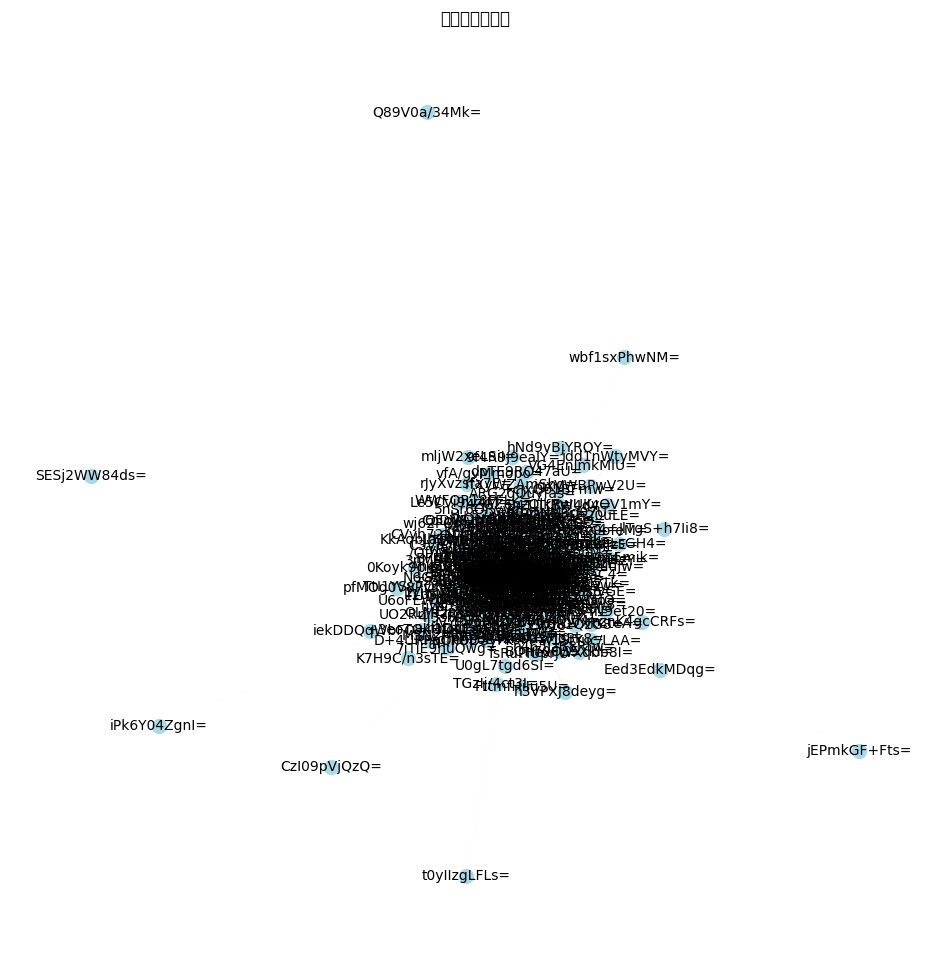

In [4]:
import matplotlib.pyplot as plt

# 设置图的布局
plt.figure(figsize=(12, 12))

# 绘制加权图，边的宽度表示航班频数
pos = nx.spring_layout(G, k=0.5)  # 使用 spring 布局来可视化图
edges = G.edges(data=True)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_size=100, node_color='lightblue')

# 绘制边，边的宽度表示航班频数（weight）
nx.draw_networkx_edges(G, pos, width=[d['weight'] / 1000 for u, v, d in edges], alpha=0.5)

# 绘制节点标签
nx.draw_networkx_labels(G, pos, font_size=10)

# 显示图形
plt.title("加权航班网络图")
plt.axis('off')
plt.show()

## 创建并训练 DeepWalk 模型

In [5]:
import numpy
print(numpy.__version__)

1.26.4


In [6]:
import networkx as nx
from node2vec import Node2Vec

1. 加载图并准备数据

In [7]:
node2vec = Node2Vec(G, 
                   dimensions=64, 
                   walk_length=3, 
                   num_walks=200, 
                   workers=4,
                   weight_key='weight')

model = node2vec.fit(window=3, 
                    min_count=1, 
                    batch_words=4)

Computing transition probabilities:   0%|          | 0/244 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 459.14it/s]


2. 获取节点的嵌入向量

In [8]:
# 获取城市嵌入表示
city_embeddings = {}
for city in G.nodes():
    city_embeddings[city] = model.wv[city]  # 从模型中提取城市嵌入

# 打印第一个城市的嵌入表示
print(city_embeddings[list(G.nodes())[0]])

[ 0.02532688 -0.06771126  0.5152158   0.28426945  0.08849953 -0.23677318
 -0.23752476 -0.11829841 -0.33026904 -0.08386174  0.3789998  -0.0169283
 -0.17380475 -0.43836284  0.34362534 -0.0306343  -0.08060385 -0.09028752
  0.04346149  0.531688    0.09779239  0.649729    0.67905474 -0.3435798
  0.46384504  0.7529808   0.0377856   0.14789072  0.03260378 -0.2837096
  0.49508357  0.20451428 -0.10260831  0.05958408 -0.03050452 -0.5336259
  0.35454708  0.3550706   0.20459983 -0.1525302   0.24114566 -0.4428468
  0.22216709 -0.12439474 -0.19734472  0.09284946  0.21369658 -0.44575417
 -0.22023098  0.3302416  -0.03799718  0.09585147  0.4696911   0.34889105
  0.36613032 -0.04066747  0.10928149 -0.05580118 -0.3731445   0.50972295
  0.46208596 -0.22577432 -0.5899173   0.2700875 ]


city_embeddings是一个字典

## 进行聚类

步骤 3：使用嵌入向量进行下游任务（例如聚类）

In [9]:
from sklearn.cluster import KMeans
import numpy as np

# 提取嵌入向量
embeddings = np.array([city_embeddings[city] for city in G.nodes()])

# 使用 KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42)  # 设置簇的数量为3
kmeans.fit(embeddings)

# 查看每个城市的聚类标签
city_labels = dict(zip(G.nodes(), kmeans.labels_))

# 打印城市及其对应的聚类标签
for city, label in city_labels.items():
    print(f"城市: {city}, 聚类标签: {label}")


城市: +3eoTOkHfoU=, 聚类标签: 1
城市: CnmNtb5MOJA=, 聚类标签: 0
城市: MSFyivV4ETI=, 聚类标签: 1
城市: UO2RniR7lJ8=, 聚类标签: 1
城市: XUXDuFGVfBM=, 聚类标签: 1
城市: +O1iBQtlFGU=, 聚类标签: 2
城市: 0J4jz5aCatU=, 聚类标签: 0
城市: 0Koyk9pJc0s=, 聚类标签: 1
城市: AKQNtuL5r6Q=, 聚类标签: 0
城市: AlGb30xUGAU=, 聚类标签: 0
城市: DInJHXgQayE=, 聚类标签: 1
城市: Eg2bemFsI9I=, 聚类标签: 0
城市: FWD6O2fHsIU=, 聚类标签: 0
城市: KETr2NAmAHE=, 聚类标签: 0
城市: KFsTKxkC/6g=, 聚类标签: 0
城市: Qe7TEMbQt6o=, 聚类标签: 2
城市: QyEgIt0M8Sg=, 聚类标签: 0
城市: So/c8CkA/Xs=, 聚类标签: 0
城市: a2cXIUGpIbw=, 聚类标签: 0
城市: gK3uAaRHrOs=, 聚类标签: 0
城市: iX2Pe2pxiqQ=, 聚类标签: 2
城市: lI1bSVMW3Tg=, 聚类标签: 2
城市: mljW2xeLSiI=, 聚类标签: 2
城市: tKjndGSl9NQ=, 聚类标签: 0
城市: yypkiQCX5lk=, 聚类标签: 2
城市: +S5aV4Y0s8w=, 聚类标签: 0
城市: /M8gHzjxpNU=, 聚类标签: 0
城市: Szk6NJM5C9Y=, 聚类标签: 0
城市: hwin1ipuzwk=, 聚类标签: 0
城市: vbo2dwBOeps=, 聚类标签: 0
城市: wSF4qXvI044=, 聚类标签: 0
城市: xIqe+QQIQXQ=, 聚类标签: 0
城市: zwVGiYamVc0=, 聚类标签: 0
城市: +cjxQ01BFmw=, 聚类标签: 2
城市: MeDwT1+vyYg=, 聚类标签: 2
城市: /qxKZMQeBus=, 聚类标签: 0
城市: 07fT2dsZOJM=, 聚类标签: 0
城市: 1/9nd1jNCE0=, 聚类标签: 0
城市: 2WRfpdop

### 保存聚类标签

In [10]:
# 首先导入 json 模块
import json
print(city_labels)

# 将字典中的所有值转换为 Python 的原生 int 类型
city_labels = {key: int(value) for key, value in city_labels.items()}

# 保存字典到 JSON 文件
with open('../../data-hh/my/encoder/city_labels_航班频率加权图标签.json', 'w') as file:
    json.dump(city_labels, file)

print("字典已保存为 city_labels.json")

{'+3eoTOkHfoU=': 1, 'CnmNtb5MOJA=': 0, 'MSFyivV4ETI=': 1, 'UO2RniR7lJ8=': 1, 'XUXDuFGVfBM=': 1, '+O1iBQtlFGU=': 2, '0J4jz5aCatU=': 0, '0Koyk9pJc0s=': 1, 'AKQNtuL5r6Q=': 0, 'AlGb30xUGAU=': 0, 'DInJHXgQayE=': 1, 'Eg2bemFsI9I=': 0, 'FWD6O2fHsIU=': 0, 'KETr2NAmAHE=': 0, 'KFsTKxkC/6g=': 0, 'Qe7TEMbQt6o=': 2, 'QyEgIt0M8Sg=': 0, 'So/c8CkA/Xs=': 0, 'a2cXIUGpIbw=': 0, 'gK3uAaRHrOs=': 0, 'iX2Pe2pxiqQ=': 2, 'lI1bSVMW3Tg=': 2, 'mljW2xeLSiI=': 2, 'tKjndGSl9NQ=': 0, 'yypkiQCX5lk=': 2, '+S5aV4Y0s8w=': 0, '/M8gHzjxpNU=': 0, 'Szk6NJM5C9Y=': 0, 'hwin1ipuzwk=': 0, 'vbo2dwBOeps=': 0, 'wSF4qXvI044=': 0, 'xIqe+QQIQXQ=': 0, 'zwVGiYamVc0=': 0, '+cjxQ01BFmw=': 2, 'MeDwT1+vyYg=': 2, '/qxKZMQeBus=': 0, '07fT2dsZOJM=': 0, '1/9nd1jNCE0=': 0, '2WRfpdopfDw=': 0, '3nMB4t9SNGw=': 0, '4J2zqjPuTyI=': 0, '4Liydpz6+ug=': 0, '4jcxTvZ+J1A=': 0, '5t+HPO9Mu/w=': 2, '7C34qLmTO2o=': 0, '81MA7ppp7mI=': 2, '8fY1ixT/Q9M=': 0, '8jksZMFqgdA=': 0, '9j4ofoSZvc4=': 0, '9obCP1myMDU=': 0, 'A7/aBOh5mik=': 0, 'AA/y/svu7dU=': 0, 'AAR1xovzan

## 二维空间聚类效果展示

步骤 4：可视化嵌入

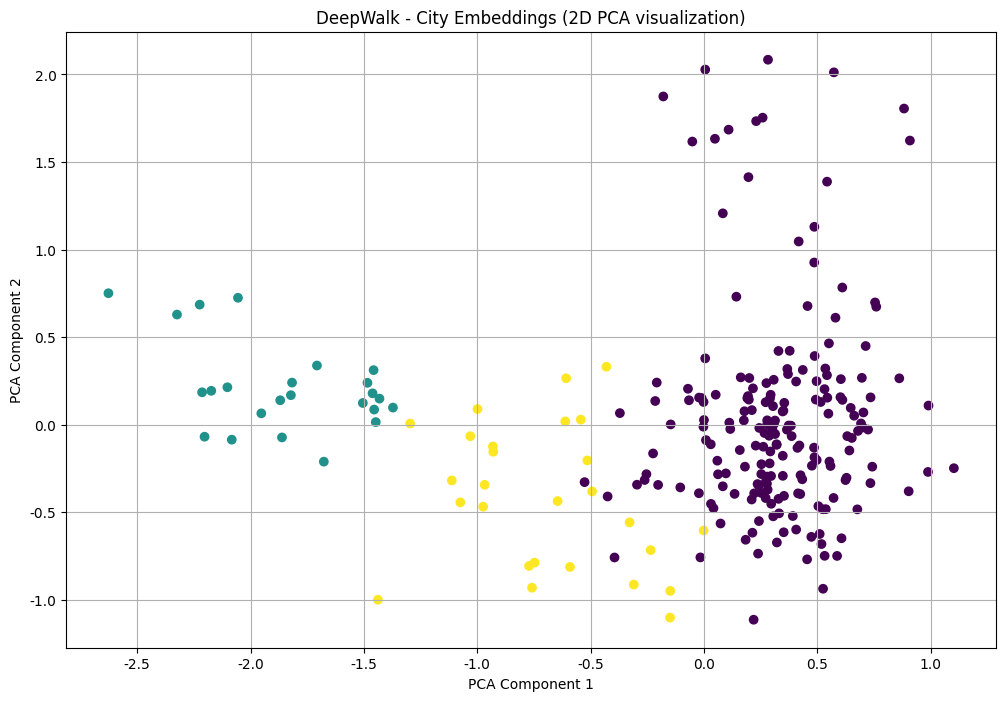

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 绘制散点图
plt.figure(figsize=(12, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans.labels_, cmap='viridis')

# 去掉为每个城市添加标签的部分
# for i, city in enumerate(G.nodes()):
#     plt.text(reduced_embeddings[i, 0] + 0.1, reduced_embeddings[i, 1] + 0.1, city, fontsize=9)

plt.title("DeepWalk - City Embeddings (2D PCA visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# 计算城市之间的相似度
similarity_matrix = cosine_similarity(embeddings)

# 打印第一个城市和其他城市的相似度
for i, city in enumerate(G.nodes()):
    print(f"城市: {city}, 相似度: {similarity_matrix[0, i]}")

城市: +3eoTOkHfoU=, 相似度: 1.0
城市: CnmNtb5MOJA=, 相似度: 0.3482770025730133
城市: MSFyivV4ETI=, 相似度: 0.8809444308280945
城市: UO2RniR7lJ8=, 相似度: 0.9121536016464233
城市: XUXDuFGVfBM=, 相似度: 0.5882093906402588
城市: +O1iBQtlFGU=, 相似度: 0.44593295454978943
城市: 0J4jz5aCatU=, 相似度: 0.08574999123811722
城市: 0Koyk9pJc0s=, 相似度: 0.8501012325286865
城市: AKQNtuL5r6Q=, 相似度: 0.2763485908508301
城市: AlGb30xUGAU=, 相似度: 0.46390923857688904
城市: DInJHXgQayE=, 相似度: 0.8250867128372192
城市: Eg2bemFsI9I=, 相似度: 0.47867095470428467
城市: FWD6O2fHsIU=, 相似度: 0.35969480872154236
城市: KETr2NAmAHE=, 相似度: 0.2774592339992523
城市: KFsTKxkC/6g=, 相似度: 0.5115922689437866
城市: Qe7TEMbQt6o=, 相似度: 0.39454385638237
城市: QyEgIt0M8Sg=, 相似度: 0.5601764917373657
城市: So/c8CkA/Xs=, 相似度: 0.1608392894268036
城市: a2cXIUGpIbw=, 相似度: 0.40307146310806274
城市: gK3uAaRHrOs=, 相似度: 0.3722028434276581
城市: iX2Pe2pxiqQ=, 相似度: 0.3572161793708801
城市: lI1bSVMW3Tg=, 相似度: 0.5486515164375305
城市: mljW2xeLSiI=, 相似度: 0.4771067500114441
城市: tKjndGSl9NQ=, 相似度: 0.2924971282482147
城市:

轮廓系数是评估聚类质量的常用指标，范围是 -1 到 1，值越大表示聚类效果越好。它同时考虑了簇内紧密度（每个点与所在簇中其他点的距离）和簇间分离度（每个点与最近簇的距离）。

值的意义：

值接近 +1：说明数据点与同簇内的点很接近，且与其他簇的点有很大区别，聚类效果好。

值接近 0：表示数据点可能位于两个簇的边界上，聚类效果一般。

值接近 -1：表示数据点可能被错误地归类到某个簇中，聚类效果差。

In [13]:
from sklearn.metrics import silhouette_score
score = silhouette_score(reduced_embeddings, kmeans.labels_)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.42131713032722473


## 保存嵌入表示

In [14]:
import numpy as np
import json

# 获取城市列表
cities = list(city_embeddings.keys())

# 将降维后的嵌入表示转换为列表格式
reduced_embeddings_list = reduced_embeddings.tolist()

# 保存城市和其对应的嵌入（将 NumPy 数组转换为列表）
city_embedding_dict = {city: reduced_embeddings[i].tolist() for i, city in enumerate(cities)}

# 将 city_embedding_dict 保存为 JSON 文件
with open('../../data-hh/my/encoder/城市嵌入编码_航班频率加权图.json', 'w') as f:
    json.dump(city_embedding_dict, f)

print("城市嵌入表示已保存。")

城市嵌入表示已保存。


In [15]:
city_embedding_dict

{'+3eoTOkHfoU=': [-1.7071812152862549, 0.3382483720779419],
 'CnmNtb5MOJA=': [0.2941875755786896, 0.17122295498847961],
 'MSFyivV4ETI=': [-2.173307418823242, 0.19382713735103607],
 'UO2RniR7lJ8=': [-1.8693082332611084, 0.13988575339317322],
 'XUXDuFGVfBM=': [-1.6769086122512817, -0.21077696979045868],
 '+O1iBQtlFGU=': [-0.999189019203186, 0.08972600847482681],
 '0J4jz5aCatU=': [0.43585795164108276, 0.3129933178424835],
 '0Koyk9pJc0s=': [-1.457365870475769, 0.31188881397247314],
 'AKQNtuL5r6Q=': [0.2735999524593353, -0.322453111410141],
 'AlGb30xUGAU=': [-0.002545722294598818, -0.011064551770687103],
 'DInJHXgQayE=': [-2.3245694637298584, 0.6291139125823975],
 'Eg2bemFsI9I=': [0.030874866992235184, -0.4517234265804291],
 'FWD6O2fHsIU=': [0.236367866396904, -0.33854547142982483],
 'KETr2NAmAHE=': [0.09666415303945541, -0.2775607705116272],
 'KFsTKxkC/6g=': [-0.07059141993522644, 0.2055736631155014],
 'Qe7TEMbQt6o=': [-0.6455975770950317, -0.43567323684692383],
 'QyEgIt0M8Sg=': [-0.104476